In [10]:
#Load the Iris dataset from sklearn.datasets.
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
import tensorflow as tf
import matplotlib.pyplot as plt

iris=load_iris()
X,y=iris.data,iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

encoder=OneHotEncoder(sparse_output=False)
y_onehot=encoder.fit_transform(y.reshape(-1,1))

X_train,X_test,y_train,y_test=train_test_split(X,y_onehot,test_size=0.2,random_state=42)

model=tf.keras.Sequential([
    tf.keras.layers.Dense(16,activation='relu',input_shape=(4,)),
    tf.keras.layers.Dense(16,activation='relu',input_shape=(4,)),
    tf.keras.layers.Dense(3,activation="softmax")
])
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

history=model.fit(X_train,y_train,validation_split=0.2,epochs=50,verbose=1)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.6133 - loss: 1.0029 - val_accuracy: 0.7083 - val_loss: 0.9625
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6094 - loss: 0.9829 - val_accuracy: 0.7083 - val_loss: 0.9400
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6302 - loss: 0.9656 - val_accuracy: 0.7500 - val_loss: 0.9194
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6510 - loss: 0.9489 - val_accuracy: 0.7500 - val_loss: 0.8981
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7122 - loss: 0.9209 - val_accuracy: 0.7500 - val_loss: 0.8762
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7018 - loss: 0.8961 - val_accuracy: 0.7917 - val_loss: 0.8546
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7174 - loss: 0.8784 - val_accuracy: 0.8333 - val_loss: 0.8330
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7695 - loss: 0.8446 - val_accuracy: 0.8333 - val_loss: 0.8109
Epoch 9/50

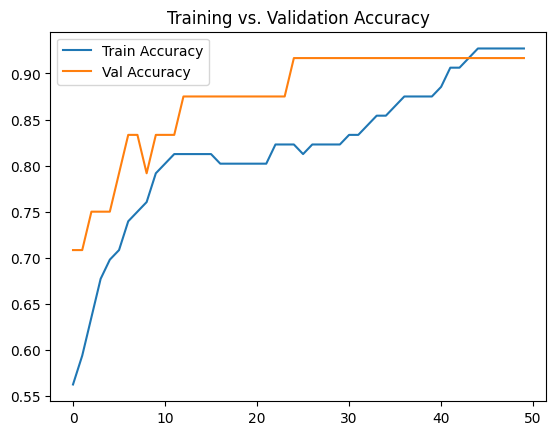

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
# Plot training & validation accuracy
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Training vs. Validation Accuracy")
plt.show()

# Evaluate on test set
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix & Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))
# # Preprocess and standardize the features
# from sklearn.preprocessing import  StandardScaler
# import sklearn.preprocessing as pre
# quantile_transform=pre.QuantileTransformer(random_state=0)
# data=quantile_transform.fit_transform(data)


In [ ]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(

#     data,target, test_size=0.33, random_state=42)

In [ ]:


# model = keras.Sequential([
#     layers.Dense(256, activation='relu', input_shape=[X_train.shape[1]]),
#     layers.BatchNormalization(),
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.3),
#     layers.BatchNormalization(),
#     layers.Dense(7, activation='relu')
# ])


In [ ]:
# # TensorFlow/Pytorch li-brary.
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# inputs = layers.Input(shape=(X_train.shape[1],), name="digits")
# x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
# x = layers.Dense(64, activation="relu", name="dense_2")(x)
# outputs = layers.Dense(3, activation="softmax", name="predictions")(x)

# model = keras.Model(inputs=inputs, outputs=outputs)


In [ ]:
# X_train, X_val, y_train, y_val = train_test_split(

#     X_train,y_train, test_size=0.33, random_state=42)

In [14]:
# #rain the model
# model.compile(
#     optimizer=keras.optimizers.RMSprop(),  # Optimizer
#     # Loss function to minimize
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     # List of metrics to monitor
#     metrics=[keras.metrics.SparseCategoricalAccuracy()],
# )

# #Report the training and validation accuracy/loss.
# model.fit(X_train, y_train, batch_size=32, epochs=100,validation_data=(X_val,y_val))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
(50, 1)
(50,)
(50, 1)


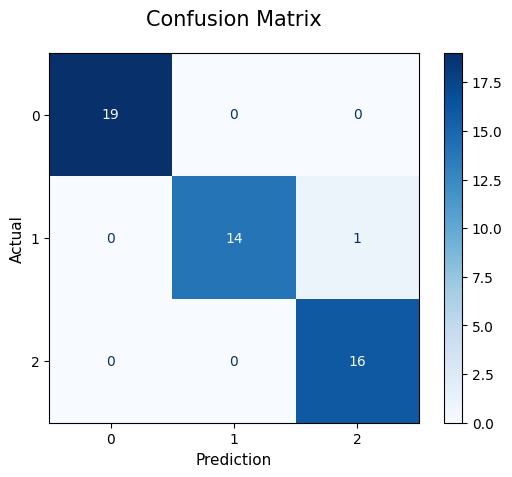

              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        19
     class 1       1.00      0.93      0.97        15
     class 2       0.94      1.00      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [ ]:

import numpy as np
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

import matplotlib.pyplot as plt

target_names = ['class 0', 'class 1', 'class 2']
classes=[0, 1, 2]
y_pred=model.predict(X_test)
print(y_test.shape)
k=np.argmax(y_pred,axis=-1)
print(k.shape)
k=np.reshape(k,(50,1))
k=pd.DataFrame(k)
print(k.shape)
cm = confusion_matrix(y_test, k, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)

plt.show()
# confusion matrix, test accu-racy, and classification report.

print(classification_report(y_test, np.argmax(y_pred,axis=-1), target_names=target_names))

2. (5)Experiment with hyperparameter tuning to optimize your FNN.
a Modify the following hyperparameters:
• Number of hidden layers or neurons.
• Learning rates.
• Batch size.
• Dropout layers
• Normalization
b Train the updated model and compare its accuracy with the original model.
c Provide updated plots for training and validation accuracy/loss, and evaluate
the new model on the test data.
d Discuss the impact of your changes and identify the best-performing configura-
tion.

In [18]:
# no of hidden layers =4
# leaniing rate=0.01
# batch_siz2 =128
# dropoutlayers=1
#normalization
from tensorflow.keras import layers


# TensorFlow/Pytorch li-brary.
import tensorflow as tf
from tensorflow import keras
# from tensorflow.keras import layers
inputs2 = layers.Input(shape=(X_train.shape[1],), name="digits")
x = layers.Dense(128, activation="relu", name="dense_1")(inputs2)
x = layers.Dense(128, activation="relu", name="dense_2")(x)
x = layers.Dense(128, activation="relu", name="dense_3")(x)
x = layers.Dense(128, activation="relu", name="dense_4")(x)
x = layers.Dense(128, activation="relu", name="dense_5")(x)
outputs = layers.Dense(3, activation="softmax", name="predictions")(x)
keras.layers.Dropout(0.2)

model2 = keras.Model(inputs=inputs2, outputs=outputs)



#rain the model
model2.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

#Report the training and validation accuracy/loss.
model2.fit(X_train, y_train, batch_size=32, epochs=100,validation_data=(X_val,y_val))

NameError: name 'X_val' is not defined

In [ ]:
y1=model.predict(X_train)
y2=model2.predict(X_train)
print("////////////////////////////old model report on train data///////////////////////////////")

print(classification_report(y_train, np.argmax(y1,axis=-1), target_names=target_names))
print("////////////////////////////new model report on train data ///////////////////////////////")

print(classification_report(y_train, np.argmax(y2,axis=-1), target_names=target_names))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
////////////////////////////old model report on train data///////////////////////////////
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        24
     class 1       1.00      1.00      1.00        20
     class 2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

////////////////////////////new model report on train data ///////////////////////////////
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        24
     class 1       0.59      1.00      0.74        20
     class 2       1.00      0.39      0.56        23

    accuracy                           0.79        67
   macro avg       0.86      0.80      0.77        67
weighted avg       0.88      0.79   

In [ ]:
y_pred_new=model2.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


(50, 1)


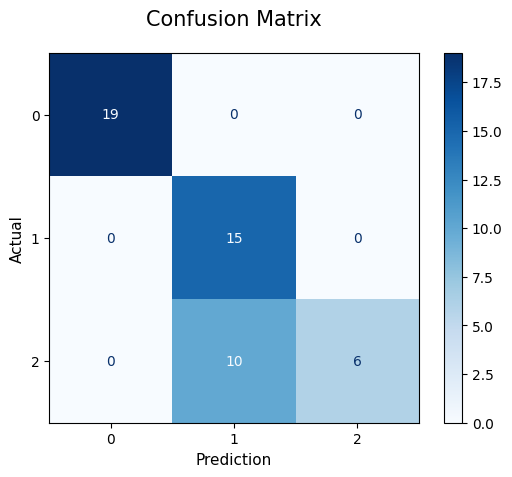

////////////////////////////old model report///////////////////////////////
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        19
     class 1       1.00      0.93      0.97        15
     class 2       0.94      1.00      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50

////////////////////new model report///////////////////////////
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00        19
     class 1       0.60      1.00      0.75        15
     class 2       1.00      0.38      0.55        16

    accuracy                           0.80        50
   macro avg       0.87      0.79      0.77        50
weighted avg       0.88      0.80      0.78        50



In [ ]:

target_names = ['class 0', 'class 1', 'class 2']
classes=[0, 1, 2]

print(y_test.shape)
k=np.argmax(y_pred_new,axis=-1)
# print(k.shape)
# k=np.reshape(k,(50,1))
# k=pd.DataFrame(k)
# print(k.shape)
cm = confusion_matrix(y_test, k, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)

plt.show()
# confusion matrix, test accu-racy, and classification report.
print("////////////////////////////old model report///////////////////////////////")
print(classification_report(y_test, np.argmax(y_pred,axis=-1), target_names=target_names))
print("////////////////////new model report///////////////////////////")

print(classification_report(y_test, np.argmax(y_pred_new,axis=-1), target_names=target_names))

In [ ]:
increasin the hidden layers and size of each layer effected the accuray
: on train data the accuracy was change to .79
: on the test data the accuracy changed to .80


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
data,target=load_iris(return_X_y=True)
datas=load_iris()
data=pd.DataFrame(data)
target=pd.DataFrame(target)

In [18]:
#question 3
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf

data=fetch_california_housing()
X=data.data
y=data.target
scalar=StandardScaler()
X=scalar.fit_transform(X)

# encoder=OneHotEncoder(sparse_output=False)
# y=encoder.fit_transform(y.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model=tf.keras.Sequential([
    tf.keras.layers.Dense(64,activation="relu",input_shape=(X.shape[1],)),
    tf.keras.layers.Dense(32,activation="relu"),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, verbose=1)



Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.0804 - mae: 0.8638 - val_loss: 0.5099 - val_mae: 0.5068
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6335 - mae: 0.4789 - val_loss: 0.4132 - val_mae: 0.4519
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3804 - mae: 0.4375 - val_loss: 0.3964 - val_mae: 0.4468
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3681 - mae: 0.4323 - val_loss: 0.3836 - val_mae: 0.4388
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3463 - mae: 0.4207 - val_loss: 0.3719 - val_mae: 0.4260
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3334 - mae: 0.4075 - val_loss: 0.3755 - val_mae: 0.4414
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3306 - mae: 0.4073 - val_loss: 0.3668 - val_mae: 0.4251
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3464 - mae: 0.4090 - val_loss: 0.3577 - val_mae: 0.4138
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - lo

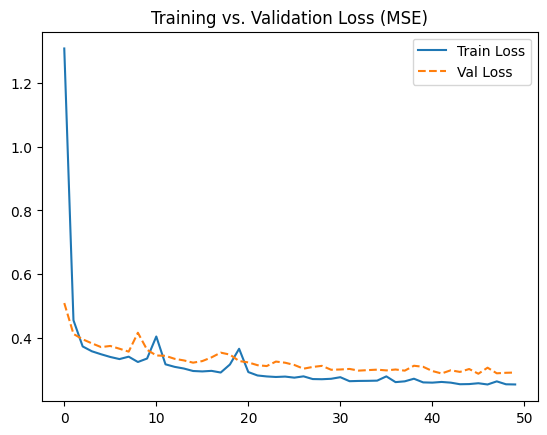

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss", linestyle="dashed")
plt.legend()
plt.title("Training vs. Validation Loss (MSE)")
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_pred = model.predict(X_test).flatten()
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

# Print Regression Metrics
print(f"📊 Test MSE: {test_mse:.4f}")
print(f"📊 Test RMSE: {test_rmse:.4f}")
print(f"📊 Test R-squared (R²): {test_r2:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
📊 Test MSE: 0.2816
📊 Test RMSE: 0.5307
📊 Test R-squared (R²): 0.7851


In [36]:
#question 4
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
data=mnist.load_data()
(X_train,y_train),(X_test,y_test)=data
X_train,X_test=X_train/255.0,X_test/255.0
X_train=X_train.reshape(-1,784)
X_test=X_test.reshape(-1,784)



[7 2 1 ... 4 5 6]


In [37]:
y_test,y_train=to_categorical(y_test,10),to_categorical(y_train,10)
model=tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation="relu",input_shape=(784,)),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")


])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [42]:
history=model.fit(X_train,y_train,validation_split=0.2,epochs=20,batch_size=128)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8138 - loss: 0.6721 - val_accuracy: 0.9508 - val_loss: 0.1766
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9519 - loss: 0.1665 - val_accuracy: 0.9624 - val_loss: 0.1309
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9700 - loss: 0.1086 - val_accuracy: 0.9675 - val_loss: 0.1171
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9767 - loss: 0.0795 - val_accuracy: 0.9711 - val_loss: 0.1004
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9818 - loss: 0.0626 - val_accuracy: 0.9725 - val_loss: 0.0919
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9856 - loss: 0.0479 - val_accuracy: 0.9721 - val_loss: 0.0934
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9870 - loss: 0.0414 - val_accuracy: 0.9738 - val_loss: 0.0891
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9900 - loss: 0.0326 - val_accuracy: 0.

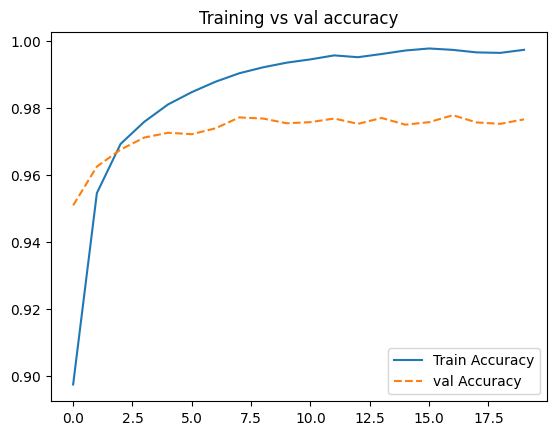

In [45]:
plt.plot(history.history["accuracy"],label="Train Accuracy")
plt.plot(history.history["val_accuracy"],label="val Accuracy",linestyle="--")
plt.legend()
plt.title("Training vs val accuracy")
plt.show()

In [46]:
# Evaluate on Test Data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


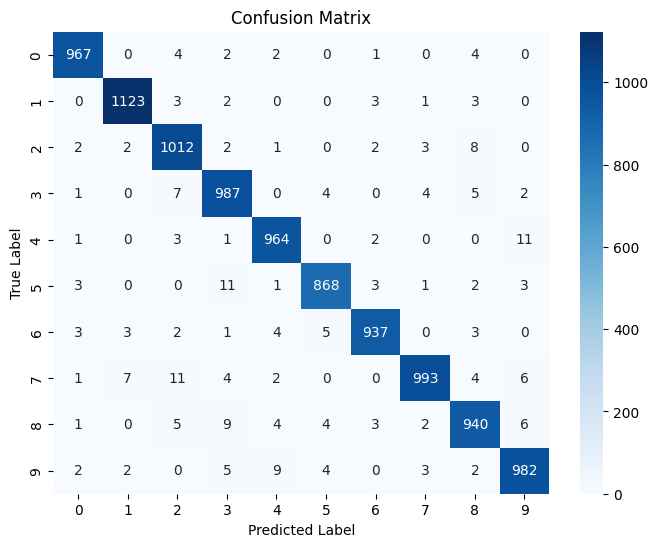

In [49]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [51]:
from sklearn.metrics import classification_report
print(f"📊 Test Accuracy: {test_acc:.4f}")
print("📊 Classification Report:\n", classification_report(y_true, y_pred))

📊 Test Accuracy: 0.9773
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.99      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

